# Experiment: 06 Prefix and Best-of-N Follow-ups

Objective:
- Inspect early-prefix geometry signal quality for Qwen dense layers.
- Visualize current Best-of-N selector behavior with available runs.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

candidate_dirs = [Path.cwd(), Path.cwd() / "notebooks", *[parent / "notebooks" for parent in Path.cwd().parents]]
for candidate in candidate_dirs:
    if (candidate / "_viz_utils.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not locate notebooks/_viz_utils.py from current working directory")

import matplotlib.pyplot as plt
import numpy as np

import _viz_utils as vu

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})


In [2]:
prefix_data = vu.load_json(vu.results_root() / "qwen_dense" / "math500_prefix" / "math500_prefix_results.json")
bestofn_models = {
    "qwen":     vu.load_json(vu.results_root() / "qwen_bestofn_full" / "math500" / "math500_best_of_n_results.json"),
    "deepseek": vu.load_json(vu.results_root() / "deepseek_bestofn_full" / "math500" / "math500_best_of_n_results.json"),
}

prefix_lengths = sorted(int(key) for key in prefix_data["prefixes"].keys())
layers = sorted(int(layer) for layer in prefix_data["layers"])


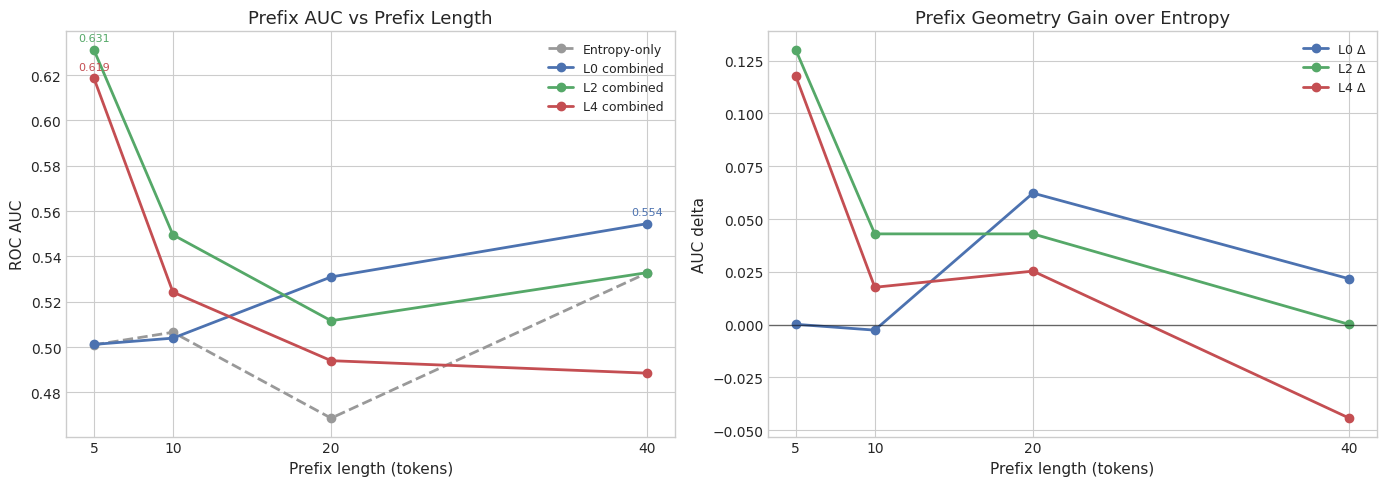

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

entropy_curve = [prefix_data["prefixes"][str(k)]["entropy_only"]["roc_auc_mean"] for k in prefix_lengths]
axes[0].plot(prefix_lengths, entropy_curve, marker="o", color="#999999", linestyle="--",
             linewidth=2, label="Entropy-only")

layer_colors = ["#4C72B0", "#55A868", "#C44E52"]
for layer, color in zip(layers, layer_colors):
    combined_curve = [prefix_data["prefixes"][str(k)]["layers"][str(layer)]["combined"]["roc_auc_mean"]
                      for k in prefix_lengths]
    axes[0].plot(prefix_lengths, combined_curve, marker="o", linewidth=2, color=color,
                 label=f"L{layer} combined")
    # Annotate best point
    best_k_idx = int(np.argmax(combined_curve))
    axes[0].annotate(f"{combined_curve[best_k_idx]:.3f}",
                     (prefix_lengths[best_k_idx], combined_curve[best_k_idx]),
                     xytext=(0, 6), textcoords="offset points", ha="center", fontsize=8, color=color)

axes[0].set_title("Prefix AUC vs Prefix Length")
axes[0].set_xlabel("Prefix length (tokens)")
axes[0].set_ylabel("ROC AUC")
axes[0].set_xticks(prefix_lengths)
axes[0].legend(loc="upper right", fontsize=9)

for layer, color in zip(layers, layer_colors):
    delta_curve = [prefix_data["prefixes"][str(k)]["layers"][str(layer)]["delta_vs_entropy"]
                   for k in prefix_lengths]
    axes[1].plot(prefix_lengths, delta_curve, marker="o", linewidth=2, color=color,
                 label=f"L{layer} Δ")

axes[1].axhline(0.0, color="black", linewidth=1, alpha=0.5)
axes[1].set_title("Prefix Geometry Gain over Entropy")
axes[1].set_xlabel("Prefix length (tokens)")
axes[1].set_ylabel("AUC delta")
axes[1].set_xticks(prefix_lengths)
axes[1].legend(loc="upper right", fontsize=9)

fig.tight_layout()
plt.show()


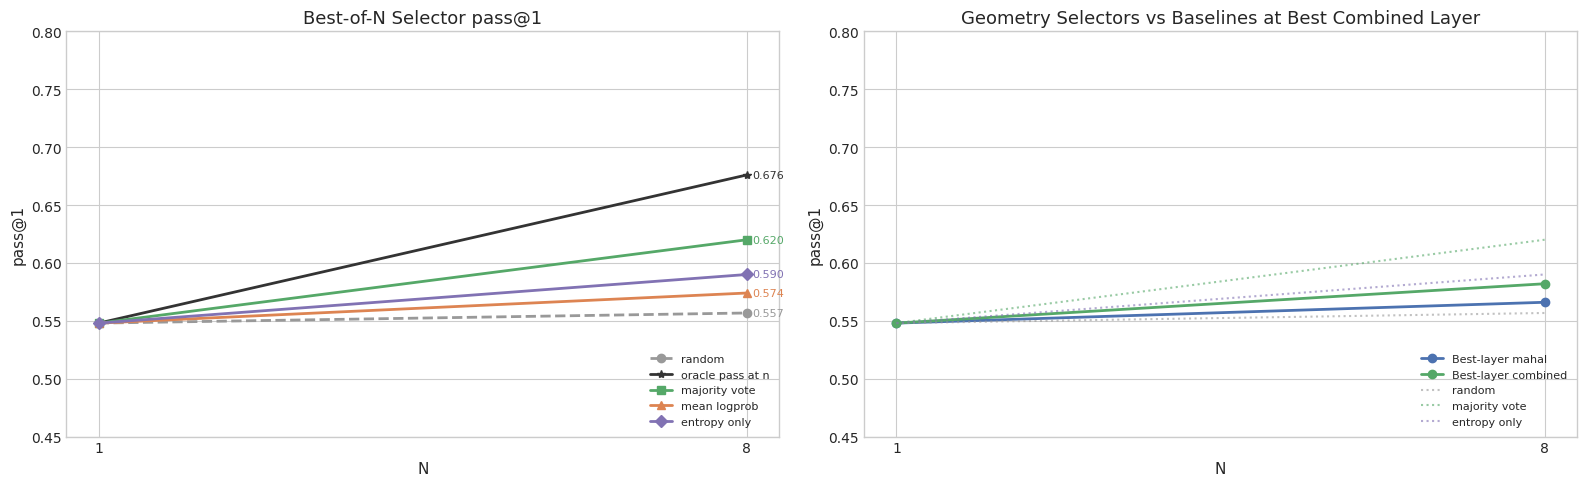

In [4]:
n_values = sorted(int(key) for key in bestofn_models["qwen"]["n_values"].keys())
selectors = ["random", "oracle_pass_at_n", "majority_vote", "mean_logprob", "entropy_only"]
selector_styles = {
    "random":         ("#999999", "--", "o"),
    "oracle_pass_at_n": ("#333333", "-",  "*"),
    "majority_vote":  ("#55A868", "-",  "s"),
    "mean_logprob":   ("#DD8452", "-",  "^"),
    "entropy_only":   ("#8172B3", "-",  "D"),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row_idx, (model_label, bestofn_data) in enumerate(bestofn_models.items()):
    for selector in selectors:
        y = []
        for n in n_values:
            entry = bestofn_data["n_values"][str(n)]["selectors"].get(selector, {})
            y.append(float(entry.get("pass_at_1_mean", np.nan)) if not entry.get("skipped") else np.nan)
        color, ls, marker = selector_styles[selector]
        axes[row_idx, 0].plot(n_values, y, marker=marker, linestyle=ls, linewidth=2, markersize=6,
                     color=color, label=selector.replace("_", " "))
        last_valid = [(n, v) for n, v in zip(n_values, y) if not np.isnan(v)]
        if last_valid:
            n_last, v_last = last_valid[-1]
            axes[row_idx, 0].annotate(f"{v_last:.3f}", (n_last, v_last),
                             xytext=(4, 0), textcoords="offset points", fontsize=8, va="center", color=color)

    axes[row_idx, 0].set_title(f"{model_label} — Best-of-N Selector pass@1")
    axes[row_idx, 0].set_xlabel("N")
    axes[row_idx, 0].set_ylabel("pass@1")
    axes[row_idx, 0].set_xticks(n_values)
    axes[row_idx, 0].set_ylim(0.45, 0.85)
    axes[row_idx, 0].legend(loc="lower right", fontsize=8)

    best_combined_vals = []
    best_mahal_vals = []
    for n in n_values:
        entry = bestofn_data["n_values"][str(n)]
        best = entry["best_combined_layer"]
        layer_key = str(best["layer"])
        best_combined_vals.append(best["combined_pass_at_1"])
        best_mahal_vals.append(entry["layers"][layer_key]["mahalanobis_only"]["pass_at_1_mean"])

    axes[row_idx, 1].plot(n_values, best_mahal_vals, marker="o", linewidth=2, color="#4C72B0", label="Best-layer mahal")
    axes[row_idx, 1].plot(n_values, best_combined_vals, marker="o", linewidth=2, color="#55A868", label="Best-layer combined")

    for selector, (color, ls, marker) in selector_styles.items():
        if selector not in ("majority_vote", "entropy_only", "random"):
            continue
        y = []
        for n in n_values:
            entry = bestofn_data["n_values"][str(n)]["selectors"].get(selector, {})
            y.append(float(entry.get("pass_at_1_mean", np.nan)) if not entry.get("skipped") else np.nan)
        axes[row_idx, 1].plot(n_values, y, linestyle=":", linewidth=1.5, color=color, alpha=0.6,
                     label=selector.replace("_", " "))

    axes[row_idx, 1].set_title(f"{model_label} — Geometry Selectors vs Baselines")
    axes[row_idx, 1].set_xlabel("N")
    axes[row_idx, 1].set_ylabel("pass@1")
    axes[row_idx, 1].set_xticks(n_values)
    axes[row_idx, 1].set_ylim(0.45, 0.85)
    axes[row_idx, 1].legend(loc="lower right", fontsize=8)

fig.tight_layout()
plt.show()

Notes:
- Prefix pilot includes `k in {5, 10, 20, 40}` and layers `{0, 2, 4}` only (qwen_dense).
- Best-of-N shows `qwen_bestofn_full` and `deepseek_bestofn_full` (N ∈ {1, 8}, 500 problems each).
- No geometry-selector variant is included in bestofn selectors yet — mahal/combined use the best combined layer heuristic.
